# Projet Puls_Events

In [1]:
# Récupération des données par API

# Récupération des agendas concernés par la région Bretagne via l'API OpenAgenda
import os

import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.environ["OPENAGENDA_API_KEY"]
load_dotenv()

url = "https://api.openagenda.com/v2/agendas"

params = {
    "search": "Bretagne",
    "official": 1,
    "size": 100,
    "if[]": ["uid", "title", "description", "slug"],
}

headers = {
    "key": API_KEY,
}

response = requests.get(url, params=params, headers=headers, timeout=30)
response.raise_for_status()

agendas = response.json()["agendas"]
df_agendas = pd.DataFrame(agendas)

display(df_agendas)



,uid,image,description,official,title,slug
0,38199897,https://img.openagenda.com/main/20e1e0c7927f46...,L’association Bretagne musées – Réseau des mus...,True,Bretagne musées,bretagnemusees
1,29692358,https://img.openagenda.com/main/87ee67f72cad49...,Les événements des 40 salles du réseau.,True,Bretagne en Scène,bretagne-en-scene
2,76975966,https://img.openagenda.com/main/8430afd7916649...,Retrouvez ici tous les événements culturels de...,True,Institut Culturel de Bretagne,icb
3,19632221,https://img.openagenda.com/main/d5dea530c7a842...,Tous les événements du collège doctoral de Bre...,True,Collège doctoral de Bretagne,college-doctoral-de-bretagne
4,11875341,https://img.openagenda.com/main/1e32871b308f4f...,Le Théâtre National de Bretagne est un Centre ...,True,Théâtre National de Bretagne,theatre-national-de-bretagne
...,...,...,...,...,...,...
95,32032698,https://img.openagenda.com/main/efac0265994b4d...,Les bibliothèques de l'université organisent d...,True,Bibliothèques - Université de Rennes,bibliotheques-univ-rennes
96,33113744,https://img.openagenda.com/main/bd14bbd21ff348...,Séminaires et colloques de l'Université Paris-...,True,Agenda de la recherche et de l'innovation,upsaclay-recherche
97,34742307,https://img.openagenda.com/main/898c22eab00c43...,L'agenda des manifestations culturelles et de ...,True,Agenda: Sortir à Chantepie,agenda-sortir-a-chantepie
98,35777956,https://img.openagenda.com/main/634c4ffd2eff4e...,"La culture, les gens, les lieux, les débats, l...",True,La Palestine à l'Affiche,palestine


In [2]:
# Récupération des événements pour chaque agenda

import time
import json
import numpy as np

load_dotenv()

DATE_MIN = "2025-08-01T00:00:00+02:00"

def recuperer_evenements_agenda(agenda_uid):
    url = f"https://api.openagenda.com/v2/agendas/{agenda_uid}/events"

    params_base = {
        "relative[]": ["current", "upcoming"],
        "timings[gte]": DATE_MIN,
        "monolingual": "fr",
        "detailed": 1,
        "size": 300,
        "sort": "timings.asc",
    }

    evenements = []
    after = None
    

    while True:
        params = params_base.copy()

        if after is not None:
            params["after[]"] = after

        response = requests.get(
            url,
            headers=headers,
            params=params,
            timeout=30,
        )
        response.raise_for_status()

        resultat = response.json()
        evenements.extend(resultat["events"])

        after = resultat.get("after")
        if after is None:
            break

    return evenements


tous_evenements = []

for agenda in df_agendas.itertuples(index=False):
    agenda_uid = agenda.uid
    evenements = recuperer_evenements_agenda(agenda_uid)

    # Conserve la provenance de chaque événement.
    for evenement in evenements:
        evenement["agenda_uid_source"] = agenda_uid
        evenement["agenda_titre_source"] = agenda.title

    tous_evenements.extend(evenements)

    # Évite d'enchaîner les appels trop vite.
    time.sleep(0.1)

df_filtre_api = pd.json_normalize(tous_evenements)

colonne_region = "location.region"
region_cible = "Bretagne"

if colonne_region not in df_filtre_api.columns:
    raise KeyError(f"Colonne région absente : {colonne_region}")

masque_region = (
    df_filtre_api[colonne_region]
    .astype("string")
    .str.strip()
    .str.casefold()
    .eq(region_cible.casefold())
)

df_filtre_api = df_filtre_api.loc[masque_region].copy()

# Normalisation explicite du type après l'aplatissement JSON
def est_booleen_compatible(valeur):
    if isinstance(valeur, (bool, np.bool_)):
        return True

    if isinstance(valeur, (int, float, np.integer, np.floating)):
        return valeur in (0, 1)

    if isinstance(valeur, str):
        return valeur.strip().lower() in {
            "true", "false", "1", "0", "oui", "non"
        }

    return False


def convertir_en_booleen(valeur):
    if valeur is None or (isinstance(valeur, float) and np.isnan(valeur)):
        return pd.NA

    if isinstance(valeur, str):
        valeur = valeur.strip().lower()

    return valeur in (True, 1, 1.0, "true", "1", "oui")


colonnes_booleennes = []

for colonne in df_filtre_api.columns:
    valeurs = df_filtre_api[colonne].dropna()

    if not valeurs.empty and valeurs.map(est_booleen_compatible).all():
        df_filtre_api[colonne] = (
            df_filtre_api[colonne]
            .map(convertir_en_booleen)
            .astype("boolean")
        )
        colonnes_booleennes.append(colonne)

print("Colonnes converties en booléen :", colonnes_booleennes)

# La colonne registration mélange des booléeens et du texte, donc on la convertit en chaîne de caractères pour éviter les erreurs de type.
df_filtre_api["registration"] = (
    df_filtre_api["registration"]
    .astype("string")
)

# La colonne tags mélange des structures json et des valeurs simples
def serialiser_json(valeur):
    if valeur is None or valeur is pd.NA:
        return pd.NA

    if isinstance(valeur, float) and np.isnan(valeur):
        return pd.NA

    if isinstance(valeur, (dict, list, tuple)):
        return json.dumps(valeur, ensure_ascii=False, default=str)

    return str(valeur)


colonnes_json = []

for colonne in df_filtre_api.columns:
    valeurs = df_filtre_api[colonne].dropna()

    contient_structure = valeurs.map(
        lambda valeur: isinstance(valeur, (dict, list, tuple))
    ).any()

    if contient_structure:
        df_filtre_api[colonne] = (
            df_filtre_api[colonne]
            .map(serialiser_json)
            .astype("string")
        )
        colonnes_json.append(colonne)

print("Colonnes converties en JSON texte :", colonnes_json)

df_filtre_api.to_parquet(
    "data/parquet_sortie/evenements_culturels_filtre.parquet",
    index=False,
)

print(f"{len(df_filtre_api)} événements récupérés")
print(f"{df_filtre_api['agenda_uid_source'].nunique()} agendas interrogés")

Colonnes converties en booléen : ['featured', 'private', 'valid', 'draft', 'accessibility.ii', 'accessibility.hi', 'accessibility.vi', 'accessibility.pi', 'accessibility.mi', 'originAgenda.official', 'location.state', 'reserve-a-la-communaute-universitaire', 'originAgenda.private', 'jaccepte-que-limage-puisse-etre-librement-utilisee-a-la-condition', 'types-devenements', 'label-ma-classe-nature', 'jatteste', 'horaires-non-communiques', 'evenement-recurrent']
Colonnes converties en JSON texte : ['keywords', 'timings', 'links', 'sourceAgendas', 'extIds', 'image.variants', 'location.disqualifiedDuplicates', 'location.duplicateCandidates', 'location.links', 'location.tags', 'location.extIds', 'thematique', 'type-devenement', 'conditions-de-participation', 'theme-jep', 'type-de-public', 'specificites', 'location.protections-appellation-et-labels', 'location.types-de-lieu', 'thematiques-info-jeunes', 'theme-jnarchi', 'location.types-de-lieux', 'categories', 'element-patrimoine-culturel-immate

In [3]:
# Récupération des données par download direct

import pandas as pd

# Chargement des sources
fichier_source = "Data/evenements-publics-openagenda.csv"


for bloc in pd.read_csv(
    fichier_source,
    sep=";",
    chunksize=10_000,
    encoding="utf-8"
):
    display(bloc.head())
    print(bloc.columns.tolist())
    break



,Identifiant,Slug,URL canonique,Titre,Description,Description longue,Détail des conditions,Mots clés,Image,Crédits image,...,Agenda d'origine (uid),Contributeur: Email,Contributeur: Téléphone,Contributeur: Nom,Contributeur: Fonction,Contributeur: organisation,Catégorie,Nom du pays,Registration,Liens additionnels
0,12413663,centre-social-st-rambert-dalbon-5148959,https://openagenda.com/tootsweet/events/centre...,Centre social St Rambert d'Albon,organisé par Centre social St Rambert d'Albon,"<p>Atelier de danses ""Folk""</p>\n<p></p>\n<p>A...",Gratuit,"breton,bretone,danse,atelier,26",NaN,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75551745,coupe-de-normandie-vtt-25-septembre-2021,https://openagenda.com/tootsweet/events/coupe-...,Coupe de Normandie VTT - 25 septembre 2021 - F...,Coupe de Normandie et Trophée Régional des Jeu...,<p>L'association Vélo Jeunes Aventure organise...,pass sanitaire obligatoire,"sport,vtt,feuguerolles bully,calvados",https://cibul.s3.amazonaws.com/60a782a88d1e433...,NaN,...,94552197.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""link"", ""value"": ""http://www.normand...",NaN
2,87153658,un-deux-trad-invite-les-tralala-lovers-8266071,https://openagenda.com/tootsweet/events/un-deu...,"Un, deux, trad invite les Tralala Lovers",avec Tralala Lovers et Viendez-Voir,"<p>Le ""fameux"" bal de Mirecourt est enfin de r...",10€,"baltrad,balfolk,danse,chant,musique,88",https://cibul.s3.amazonaws.com/07ad84a33c24458...,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[{""data"": {""author_url"": ""https://www.youtube...."
3,35021962,totalement-90-6588587,https://openagenda.com/tootsweet/events/totale...,Totalement 90,"WORLDS APART, LARUSSO, INDRA, BORIS, YANNICK E...",<p>Totalement 90 accueillera le chanteur Boris...,Tarifs: de 35€ à 45€,"chanson,spectacle,show,Longjumeau,Essonne,Ile ...",https://cibul.s3.amazonaws.com/9f486cc452114f1...,NaN,...,15004001.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""01 69 09 09 09""}]",NaN
4,71691788,atelier-signer-avec-bebe-avec-laure-giry,https://openagenda.com/issy-com/events/atelier...,Atelier « Signer avec bébé » avec Laure Giry,"Séance N°1 sur 2, pour découvrir la communicat...",NaN,Sur réservation auprès d’A3N,"signer,bébé,gestuelle bébé,communication avec ...",https://cibul.s3.amazonaws.com/event_atelier-s...,NaN,...,80515007.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""06 81 91 43 44""},...",NaN


['Identifiant', 'Slug', 'URL canonique', 'Titre', 'Description', 'Description longue', 'Détail des conditions', 'Mots clés', 'Image', 'Crédits image', 'Aperçu', 'Image source', 'Dernière mise à jour', 'Résumé horaires', 'Première date - Début', 'Première date - Fin', 'Dernière date - Début', 'Dernière date - Fin', 'Horaires détaillés', "Code d'accessibilité", 'Accessibilité', 'Identifiant du lieu', 'Coordonnées géographiques', 'Nom du lieu', 'Adresse', 'Arrondissement', 'Code INSEE', 'Code postal', 'Ville', 'Département', 'Région', 'Pays', 'Image du lieu', "Crédits de l'image du lieu", 'Téléphone du lieu', 'Site web du lieu', 'Liens du lieu', 'Tags du lieu', 'Description du lieu', 'Accès / Itinéraire', 'Événement physique ou en ligne', "Lien d'accès en ligne", "État de l'événement", 'Age minimum', 'Age maximum', "Agenda d'origine (titre)", "Agenda d'origine (uid)", 'Contributeur: Email', 'Contributeur: Téléphone', 'Contributeur: Nom', 'Contributeur: Fonction', 'Contributeur: organisati

In [4]:
# conversion en fichiers parquet
for i, bloc in enumerate(pd.read_csv(fichier_source,  sep=";", chunksize=100_000)):
    bloc.to_parquet(f"data/parquet_sortie/part-{i:04d}.parquet", index=False)

In [5]:
# Analyse du fichier parquet
df = pd.read_parquet("data/parquet_sortie/part-0000.parquet")
df.describe()

,Identifiant,Identifiant du lieu,Age minimum,Age maximum,Agenda d'origine (uid),Contributeur: Email,Contributeur: Téléphone,Contributeur: Nom,Contributeur: Fonction,Contributeur: organisation,Catégorie
count,1.000000e+05,9.977200e+04,16093.000000,22098.000000,9.923400e+04,0.0,0.0,0.0,0.0,0.0,0.0
mean,4.995233e+07,5.026781e+07,9.558069,79.788216,3.974640e+07,NaN,NaN,NaN,NaN,NaN,NaN
std,2.882509e+07,2.882240e+07,6.492012,37.267035,2.926612e+07,NaN,NaN,NaN,NaN,NaN,NaN
min,1.225000e+03,2.700000e+03,1.000000,1.000000,5.746000e+03,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.496990e+07,2.519298e+07,6.000000,80.000000,9.977986e+06,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.993728e+07,5.031024e+07,8.000000,99.000000,3.849588e+07,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.486513e+07,7.526018e+07,12.000000,99.000000,6.192520e+07,NaN,NaN,NaN,NaN,NaN,NaN
max,9.999874e+07,9.999928e+07,75.000000,121.000000,9.995489e+07,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Filtre sur la région et la date

#print(bloc.columns.tolist())
df_filtre = df[
    (df["Région"] == "Bretagne") &
    (df["Dernière date - Début"] >= "2025-08-01")
].copy()

df_filtre.to_parquet("data/parquet_sortie/part-0000-filtre.parquet", index=False)

# Suppression des identifiants
df_filtre = df_filtre.drop(columns=[df_filtre.columns[0], df_filtre.columns[21]]).copy()

df_filtre.head()
df_filtre.info()

<class 'pandas.DataFrame'>
Index: 1050 entries, 2130 to 98848
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Slug                            1050 non-null   str    
 1   URL canonique                   1050 non-null   str    
 2   Titre                           1039 non-null   str    
 3   Description                     1039 non-null   str    
 4   Description longue              936 non-null    str    
 5   Détail des conditions           625 non-null    str    
 6   Mots clés                       520 non-null    str    
 7   Image                           968 non-null    str    
 8   Crédits image                   558 non-null    str    
 9   Aperçu                          968 non-null    str    
 10  Image source                    968 non-null    str    
 11  Dernière mise à jour            1050 non-null   str    
 12  Résumé horaires                 1050 non-null 

# Reprise du traitement sur le df issu de l'API

In [7]:
print(df_filtre_api.dtypes)

longDescription                         str
country                                 str
featured                            boolean
private                             boolean
keywords                             string
                                     ...   
titre-de-levemement-resume              str
tarifs-conditions-de-paticpation     string
horaires-non-communiques            boolean
evenement-recurrent                 boolean
prix                                    str
Length: 246, dtype: object


In [8]:
df_filtre_api.count()

longDescription                     2356
country                             2386
featured                            2386
private                             2386
keywords                            1145
                                    ... 
titre-de-levemement-resume             3
tarifs-conditions-de-paticpation       3
horaires-non-communiques               2
evenement-recurrent                    3
prix                                   2
Length: 246, dtype: int64

In [9]:
# Tests unitaires
df_test = pd.read_parquet("data/parquet_sortie/evenements_culturels_filtre.parquet")
print(df_test.head())
print(df_test.shape)
print("Régions filtrées : "+ df_test["location.region"].unique())

# Vérification : True si toutes les dates respectent la condition
seuil_date = pd.Timestamp(DATE_MIN)

def possede_une_occurrence_apres_seuil(timings_json):
    timings = json.loads(timings_json)

    return any(
        pd.Timestamp(creneau["begin"]) >= seuil_date
        for creneau in timings
        if creneau.get("begin")
    )

controle = df_test["timings"].apply(
    possede_une_occurrence_apres_seuil
).all()

print("Contrôle de date :", controle)

                                     longDescription             country  \
0  Comment la Bretagne du 19e siècle se développe...  France (Métropole)   
1  ​Le Musée de Bretagne conserve de nombreuses c...  France (Métropole)   
2  Les photographies qu'elle ramène de ces campag...  France (Métropole)   
3  À travers des documents d'archives, des journa...  France (Métropole)   
4  Pour le savoir, laissez-vous embarquer dans l'...  France (Métropole)   

   featured  private         keywords                         dateRange  \
0     False    False             [""]   2 septembre 2025 - 31 août 2028   
1     False    False             [""]       20 juin 2026 - 31 août 2028   
2     False    False             [""]               9 juin - 31 octobre   
3     False    False  ["expoDreyfus"]             27 juin - 12 décembre   
4     False    False     ["vacances"]  4 octobre 2025 - 29 octobre 2026   

       timezone                                      imageCredits  \
0  Europe/Paris        

In [12]:
# Nettoyage des données
def valeurs_manquantes(serie):
    if pd.api.types.is_string_dtype(serie) or serie.dtype == "object":
        return serie.isna() | serie.astype("string").str.strip().eq("")
    return serie.isna()

rapport_colonnes = pd.DataFrame({
    "type": df_filtre_api.dtypes.astype(str),
    "valeurs_manquantes": {
        colonne: valeurs_manquantes(df_filtre_api[colonne]).sum()
        for colonne in df_filtre_api.columns
    },
})

rapport_colonnes["taux_remplissage"] = (
    1 - rapport_colonnes["valeurs_manquantes"] / len(df_filtre_api)
).round(3)

rapport_colonnes = rapport_colonnes.sort_values("taux_remplissage")

display(rapport_colonnes)


,type,valeurs_manquantes,taux_remplissage
motive,object,2386,0.0
nm-ignorer-heure-debut,object,2386,0.0
nm-ignorer-heure-fin,object,2386,0.0
nm-public,object,2386,0.0
nm-thematiques,object,2386,0.0
...,...,...,...
accessibility.vi,boolean,0,1.0
originAgenda.uid,float64,0,1.0
accessibility.mi,boolean,0,1.0
lastTiming.begin,str,0,1.0


In [13]:
colonnes_peu_remplies = rapport_colonnes.query(
    "taux_remplissage < 0.10"
)

display(colonnes_peu_remplies)

,type,valeurs_manquantes,taux_remplissage
motive,object,2386,0.000
nm-ignorer-heure-debut,object,2386,0.000
nm-ignorer-heure-fin,object,2386,0.000
nm-public,object,2386,0.000
nm-thematiques,object,2386,0.000
...,...,...,...
location.disqualifiedDuplicates,string,2284,0.043
location.access.en,str,2178,0.087
location.access.it,str,2178,0.087
location.access.es,str,2178,0.087


In [14]:
seuil_remplissage = 0.10

colonnes_a_supprimer = rapport_colonnes.index[
    rapport_colonnes["taux_remplissage"] < seuil_remplissage
].tolist()

df_nettoye = (
    df_filtre_api
    .drop(columns=colonnes_a_supprimer)
    .drop_duplicates()
    .copy()
)

# Nettoyage des champs texte
colonnes_texte = df_nettoye.select_dtypes(
    include=["object", "string"]
).columns

for colonne in colonnes_texte:
    df_nettoye[colonne] = (
        df_nettoye[colonne]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

df_nettoye.to_parquet(
    "data/parquet_sortie/evenements_culturels_nettoye.parquet",
    index=False,
)

print("Colonnes supprimées :", colonnes_a_supprimer)
print("Dimensions après nettoyage :", df_nettoye.shape)

Colonnes supprimées : ['motive', 'nm-ignorer-heure-debut', 'nm-ignorer-heure-fin', 'nm-public', 'nm-thematiques', 'tarifs-detail', 'image', 'nm-types', 'nm-gratuit', 'nm-carte-blanche', 'nm-diffusion', 'thematique-economie', 'thematique-environnement', 'thematique-loisirs', 'thematique-sport', 'particularites', 'cibles', 'musique-du-monde', 'genre', 'participation', 'thematique-tourisme', 'entreelibre', 'thematiques-metropolitaines', 'organisateur', 'thematique-culture', 'image.originalName', 'theme', 'element-patrimoine-culturel-immateriel', 'types-de-public', 'image.extension', 'theme-jnarchi', 'type_devenements', 'champ-art', 'discipline', 'category-group', 'thematiques-specifiques-bu', 'thematique-patrimoine', 'thematique-social-societe', 'equipement', 'type-de-public-vise', 'categorie', 'conseil', 'thematiques-info-jeunes', 'titre-de-levemement-resume', 'autres-types-despace-nuit-eventuellement-non-listes-ci-dessus', 'prix', 'tarifs-conditions-de-paticpation', 'votre-msa', 'diffus

# Génération des embeddings

In [15]:
import os
from pathlib import Path
import numpy as np

from dotenv import load_dotenv
from mistralai.client import Mistral

from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv(Path.cwd() / ".env")
api_key = os.environ["MISTRAL_API_KEY"]

# Colonnes utiles à la recherche sémantique
colonnes_embedding = [
   "title",
   "description",
   "longDescription",
   "keywords",
   "location.city",
   "location.region",
]

# Une ligne DataFrame devient un document texte
documents = (
    df_nettoye[colonnes_embedding]
    .fillna("")
    .astype(str)
    .apply(
        lambda ligne: "\n".join(
            f"{colonne}: {valeur.strip()}"
            for colonne, valeur in ligne.items()
            if valeur.strip()
        ),
        axis=1,
    )
)

# Chunking et traitement des documents vides
mask = documents.str.strip().ne("")
documents = documents.loc[mask]

# Découpe les documents longs avant leur vectorisation.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1_000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = []

for index_evenement, texte in documents.items():
    for numero_chunk, texte_chunk in enumerate(splitter.split_text(texte)):
        chunks.append({
            "index_evenement": index_evenement,
            "numero_chunk": numero_chunk,
            "texte_chunk": texte_chunk,
        })

df_embeddings = pd.DataFrame(chunks)

documents = df_embeddings["texte_chunk"].tolist()

# Appels en lots pour traiter les événements proprement
taille_lot = 100
embeddings = []

with Mistral(api_key=api_key) as mistral:
    for debut in range(0, len(documents), taille_lot):
        lot = documents[debut:debut + taille_lot]

        reponse = mistral.embeddings.create(
            model="mistral-embed",
            inputs=lot,
        )

        embeddings.extend(
            item.embedding
            for item in sorted(
                reponse.data, 
                key=lambda item: item.index if item.index is not None else -1,)
        )

# Conserve le texte envoyé et son vecteur sur chaque événement
df_embeddings["embedding"] = embeddings

df_embeddings.to_parquet(
    "data/parquet_sortie/evenements_embeddings_mistral.parquet",
    index=False,
)

print(f"{len(df_embeddings)} embeddings créés.")
print(f"Dimension d'un embedding : {len(embeddings[0])}")

3541 embeddings créés.
Dimension d'un embedding : 1024


In [16]:
df_embeddings.head()

,index_evenement,numero_chunk,texte_chunk,embedding
0,0,0,title: La Bretagne de 1850 à nos jours\ndescri...,"[-0.022064208984375, 0.0255584716796875, 0.017..."
1,1,0,title: L'affaire Dreyfus à Rennes\ndescription...,"[-0.036041259765625, 0.030303955078125, 0.0274..."
2,2,0,title: Anita Conti - La dame de la mer\ndescri...,"[-0.0269775390625, 0.00853729248046875, 0.0431..."
3,3,0,title: Visite : l'Affaire Dreyfus à Rennes\nde...,"[-0.035888671875, 0.03399658203125, 0.03555297..."
4,4,0,title: La Bretagne de 1850 à nos jours\ndescri...,"[-0.01751708984375, 0.040435791015625, 0.04043..."


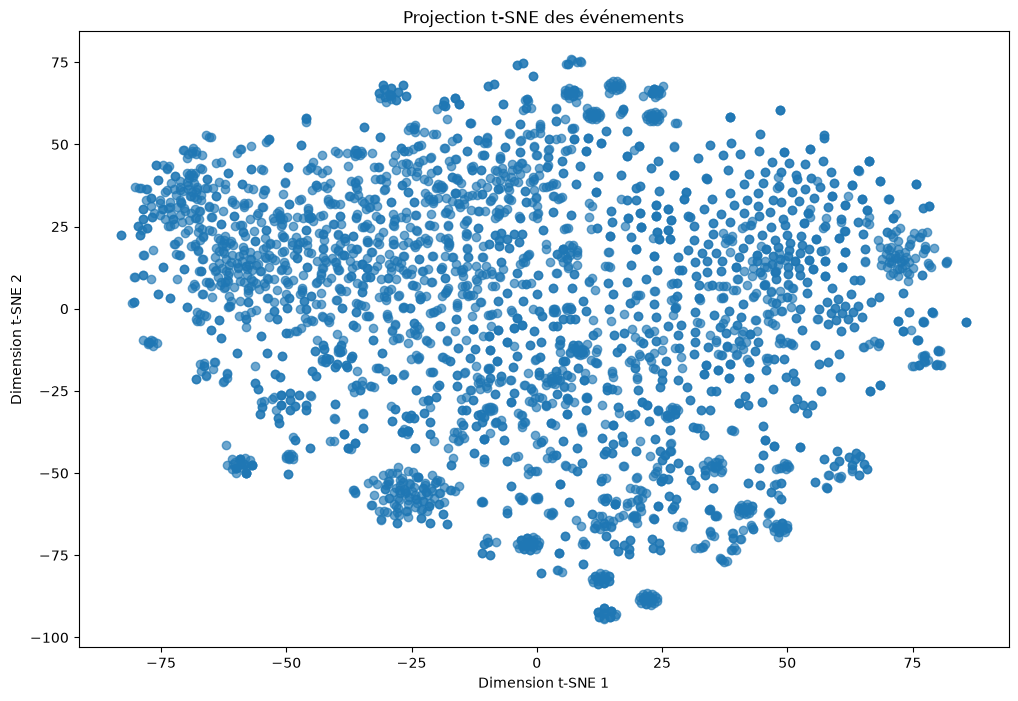

In [17]:
# Réduction de dimension pour les embeddings Mistral

# Conversion de la colonne contenant les vecteurs Mistral en matrice NumPy
matrice_embeddings = np.asarray(df_embeddings["embedding"].tolist())

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1_000,
    random_state=42,
)

embeddings_2d = tsne.fit_transform(matrice_embeddings)

df_embeddings["tsne_x"] = embeddings_2d[:, 0]
df_embeddings["tsne_y"] = embeddings_2d[:, 1]

plt.figure(figsize=(12, 8))
plt.scatter(
    df_embeddings["tsne_x"],
    df_embeddings["tsne_y"],
    alpha=0.65,
)

plt.title("Projection t-SNE des événements")
plt.xlabel("Dimension t-SNE 1")
plt.ylabel("Dimension t-SNE 2")
plt.show()